In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [15]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [16]:
file_csv = '../../../../data/phenotypic_obregon_151617_seven.csv'
svr = SVR_Prediction(kernel=SvrKernelEnum.LINEAR)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PASS,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

Launched SVR

In [17]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [18]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [19]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 40.668621654421166
R2 -> 0.8282867531727921
MAPE -> 0.04166339977578189


{'d2_absolute_error_score': 0.6404251059230599,
 'd2_pinball_score': 0.6404251059230599,
 'd2_tweedie_score': 0.8282867531727921,
 'explained_variance_score': 0.8285783707119231,
 'max_error': 209.2504595620544,
 'mean_absolute_error': 25.090239358057772,
 'mean_absolute_percentage_error': 0.04166339977578189,
 'mean_gamma_deviance': 0.0046365211456682025,
 'mean_poisson_deviance': 2.6679618535669385,
 'mean_squared_error': 1653.9367872704543,
 'mean_squared_log_error': 0.004681929249352838,
 'median_absolute_error': 10.426918393507663,
 'r2_score': 0.8282867531727921,
 'root_mean_squared_error': 40.668621654421166,
 'root_mean_squared_log_error': 0.06842462458320717}

Plots:

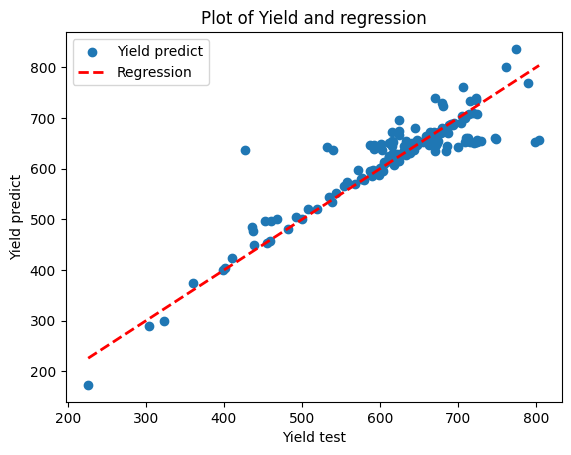

In [20]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

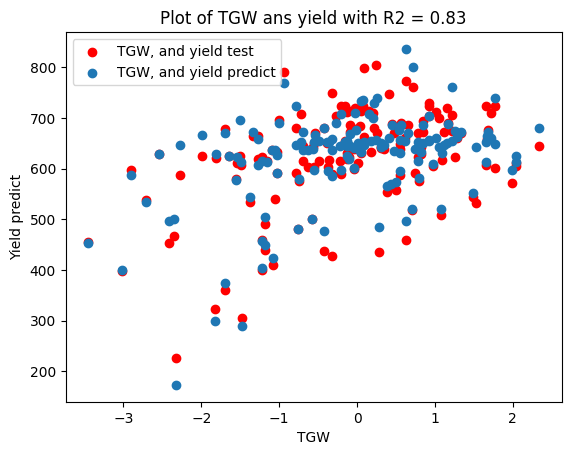

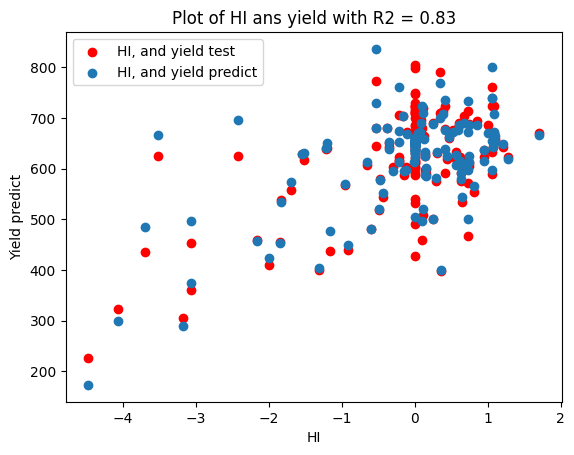

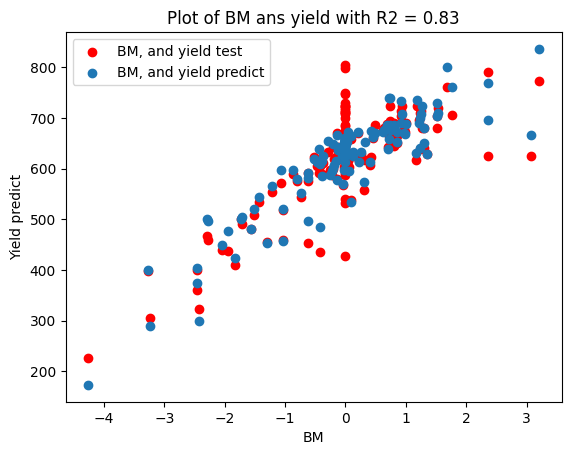

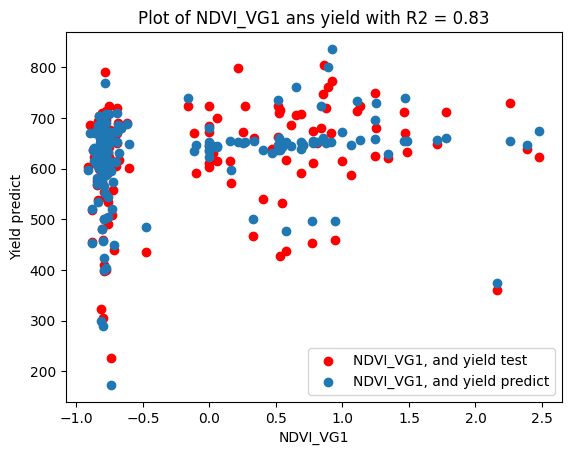

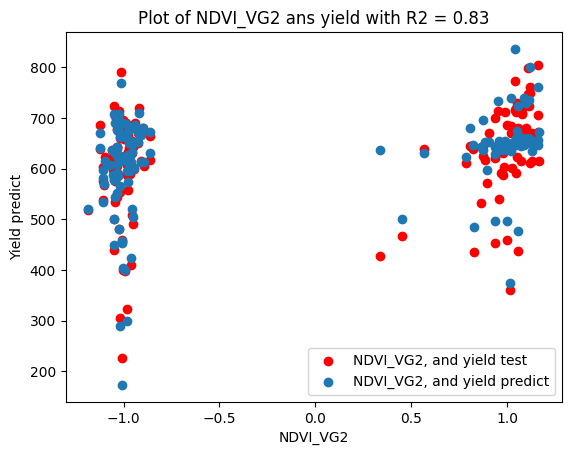

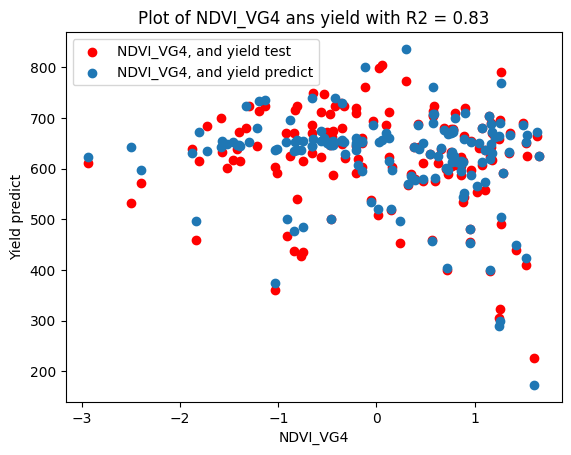

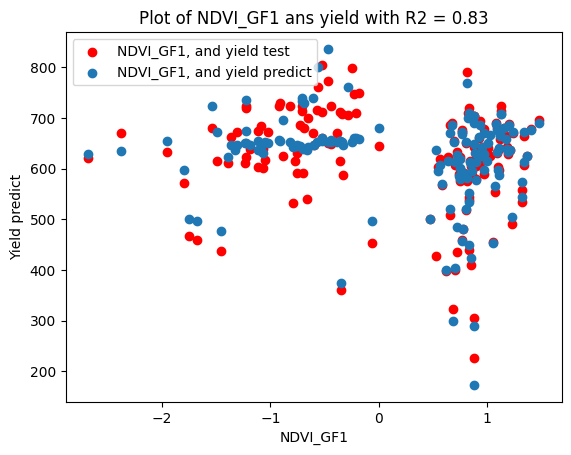

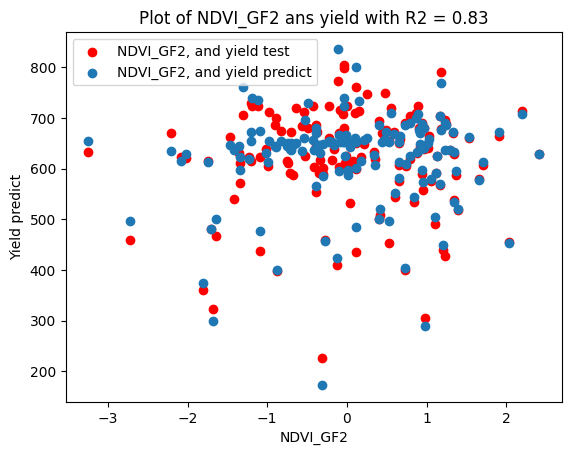

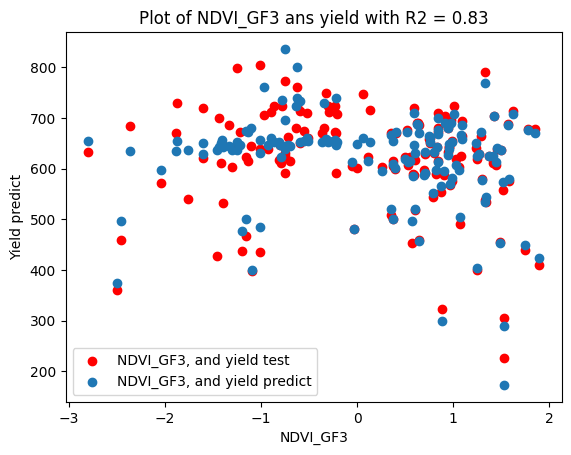

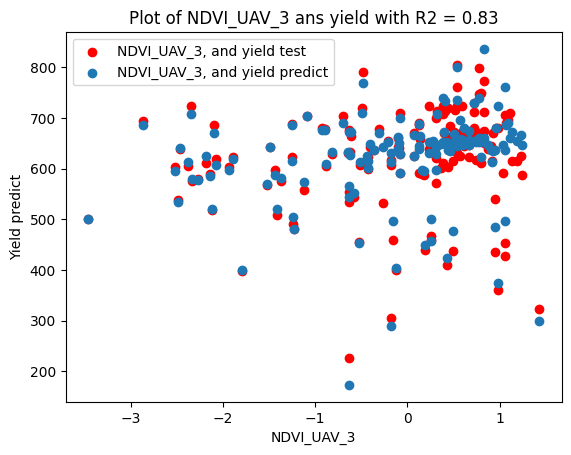

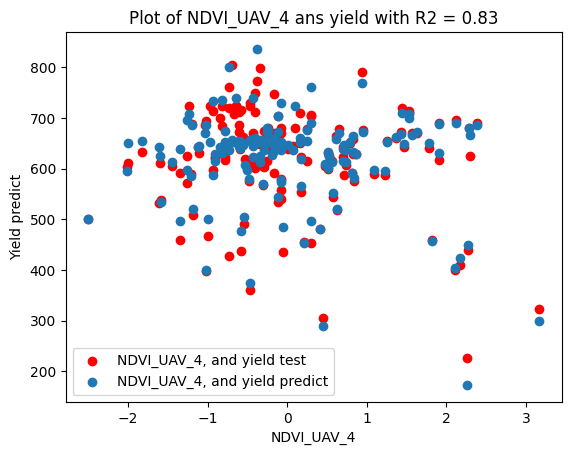

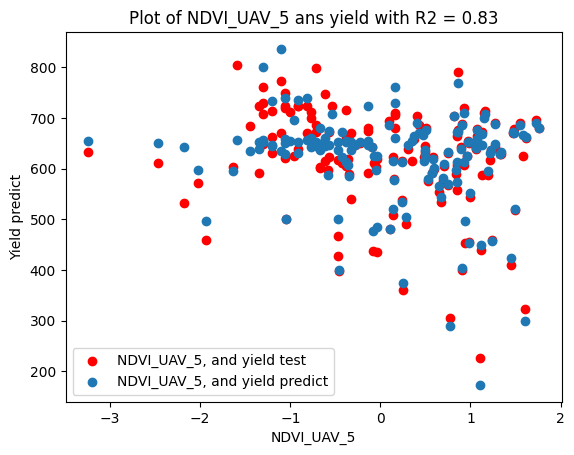

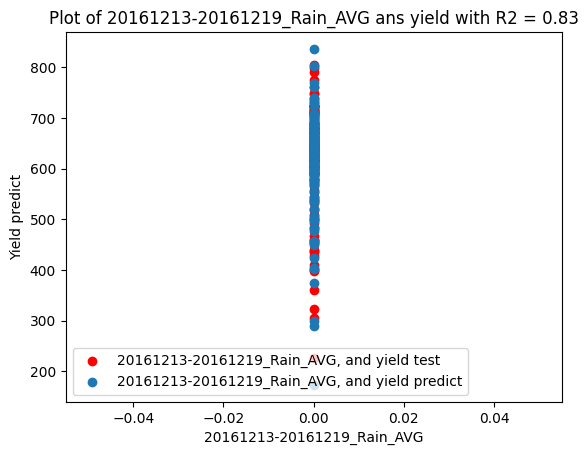

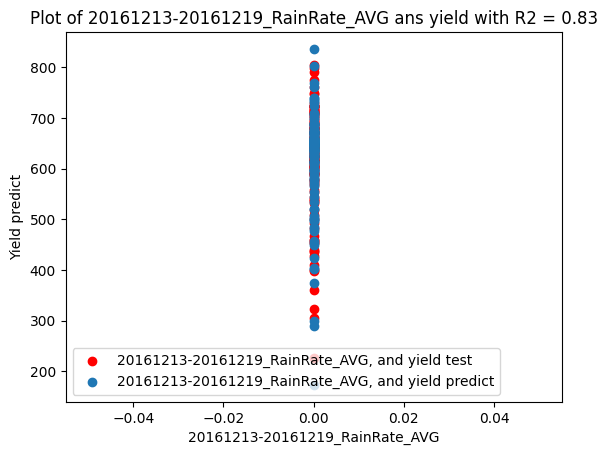

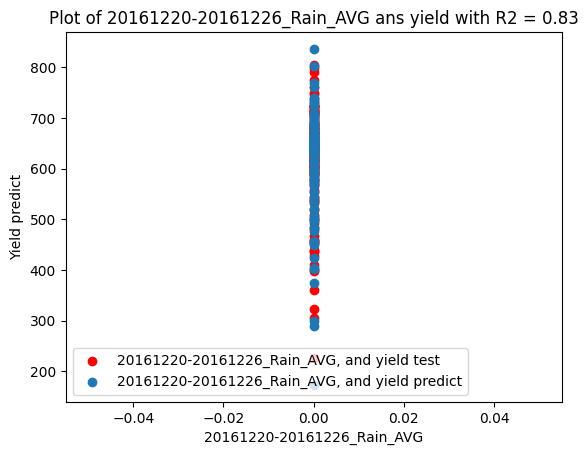

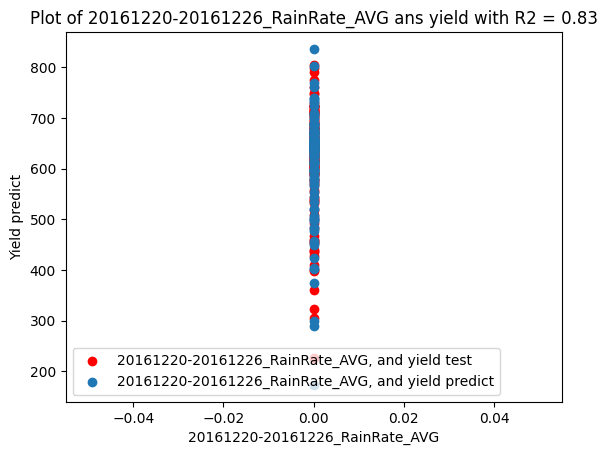

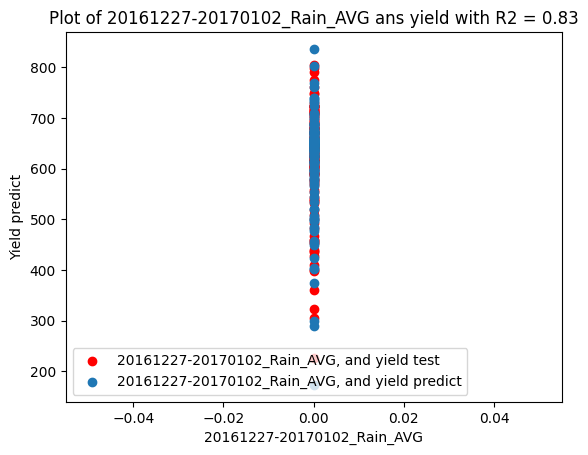

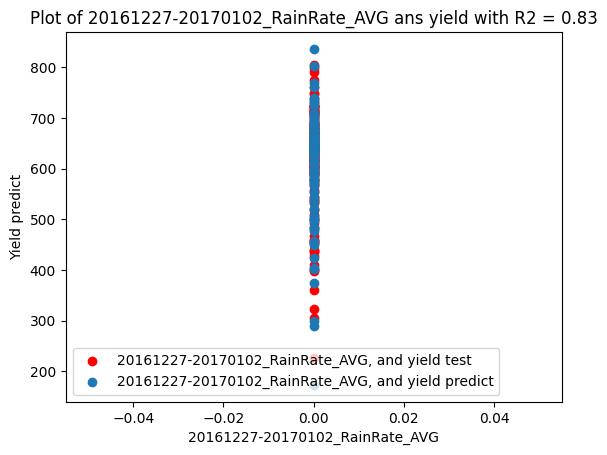

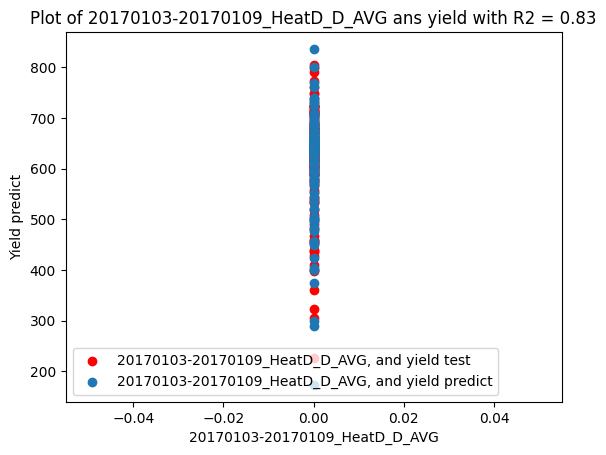

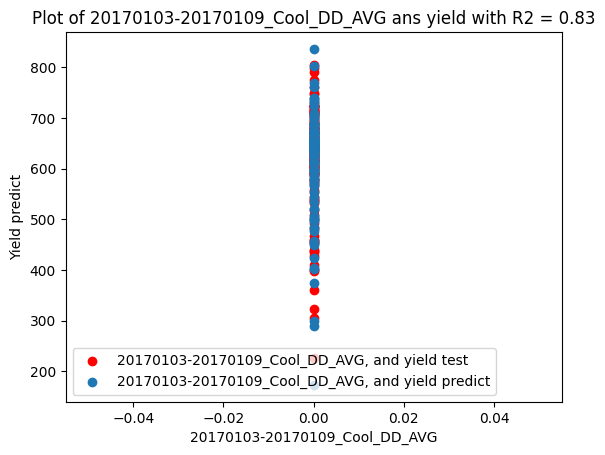

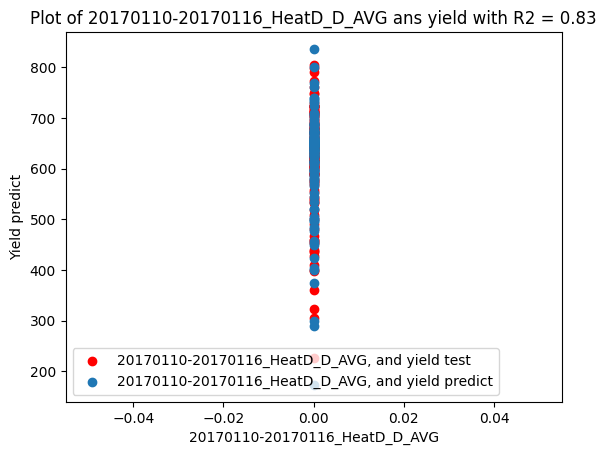

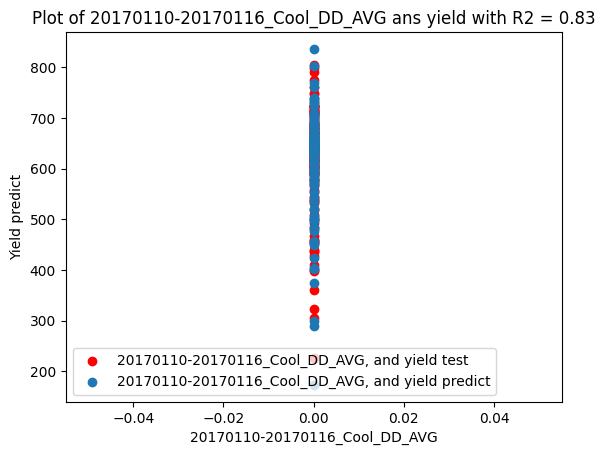

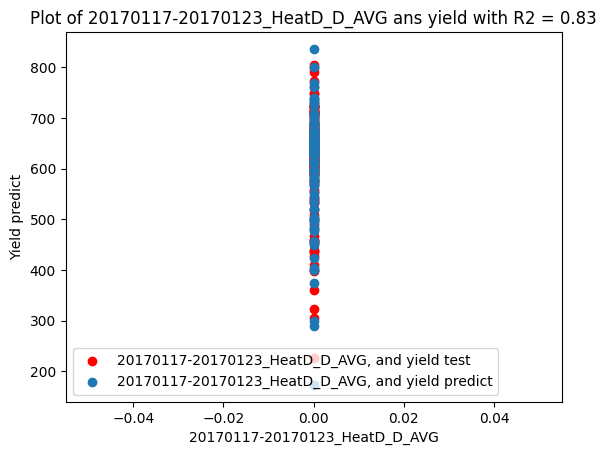

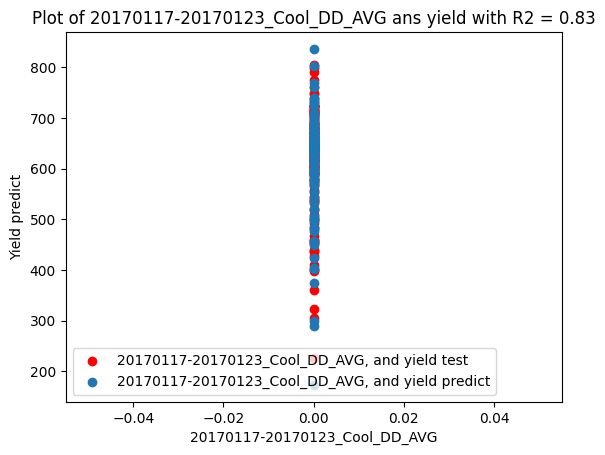

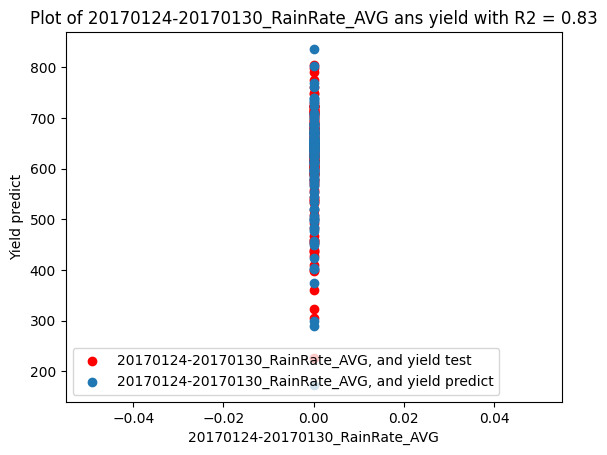

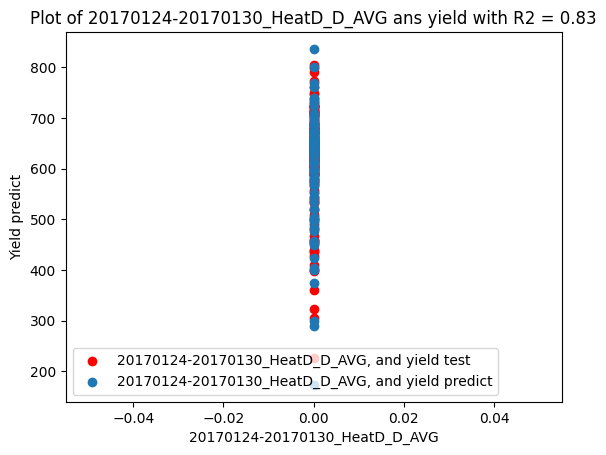

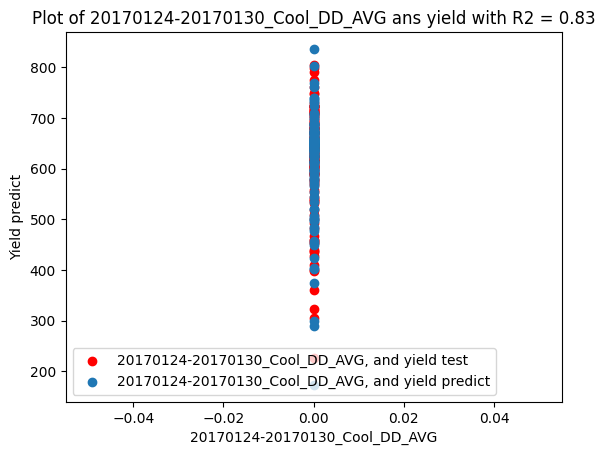

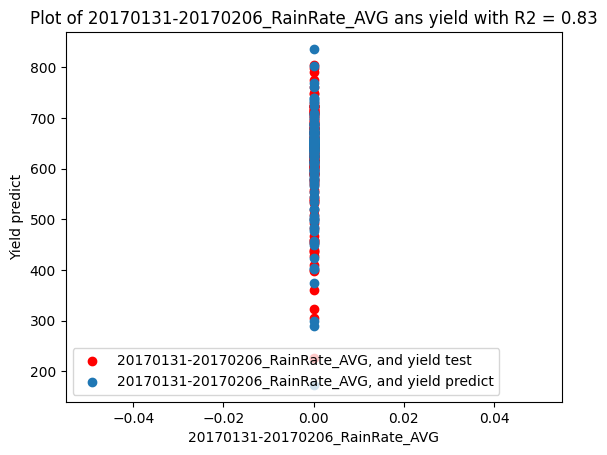

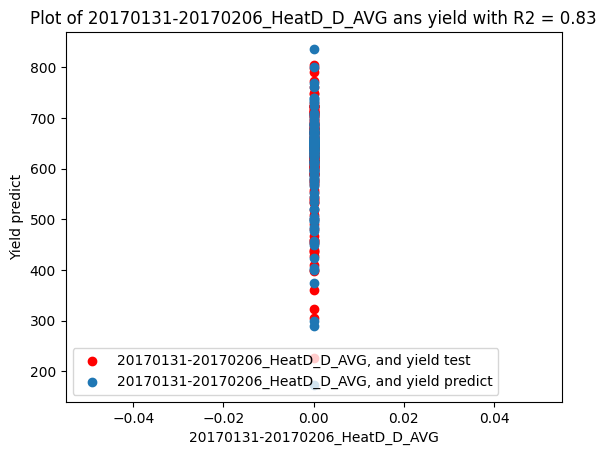

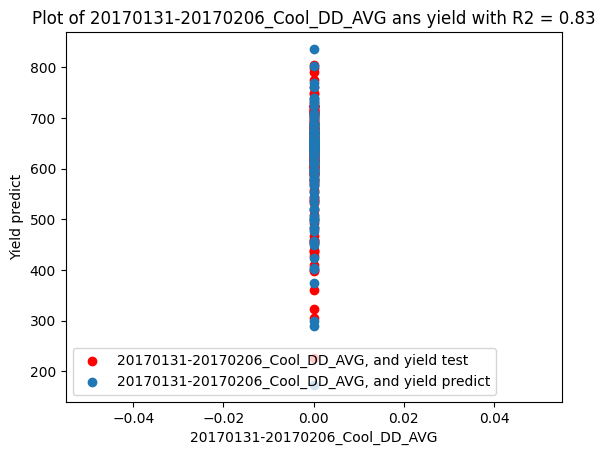

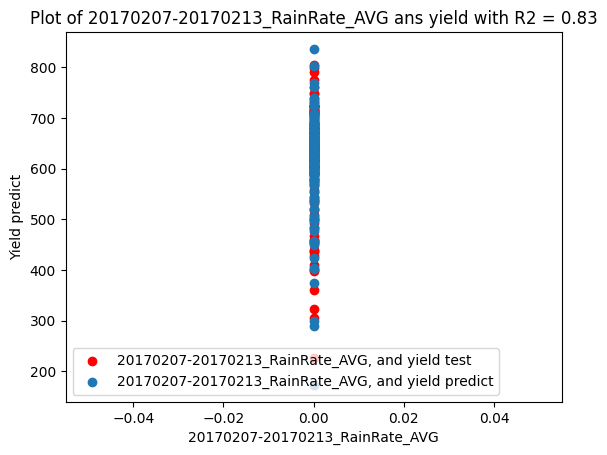

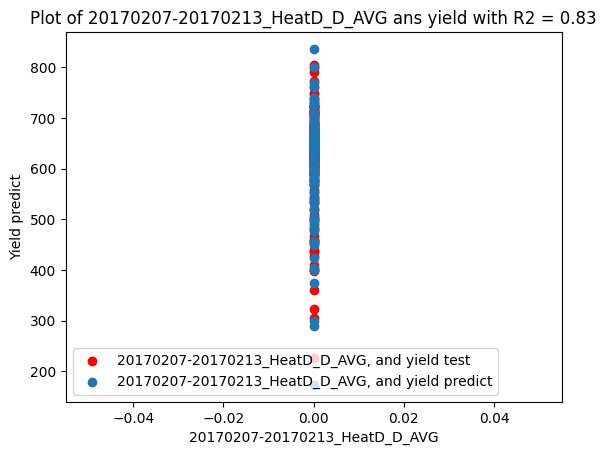

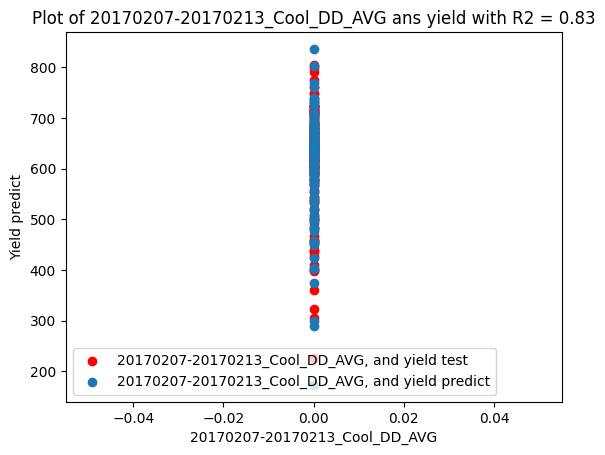

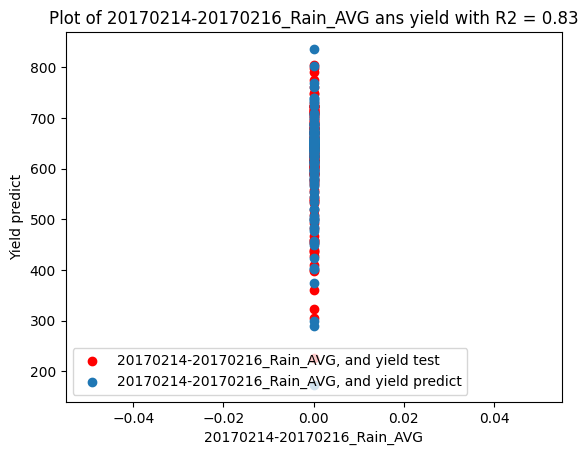

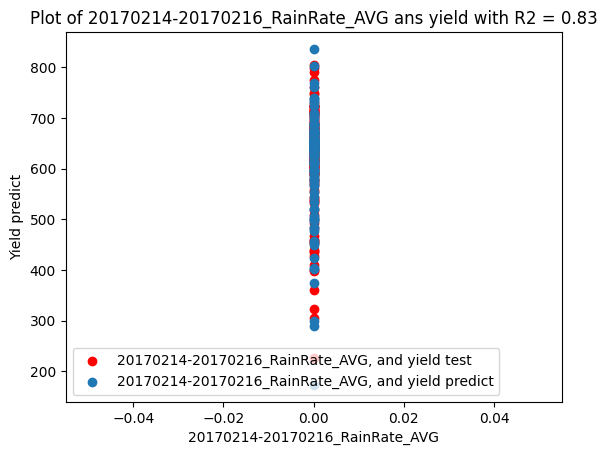

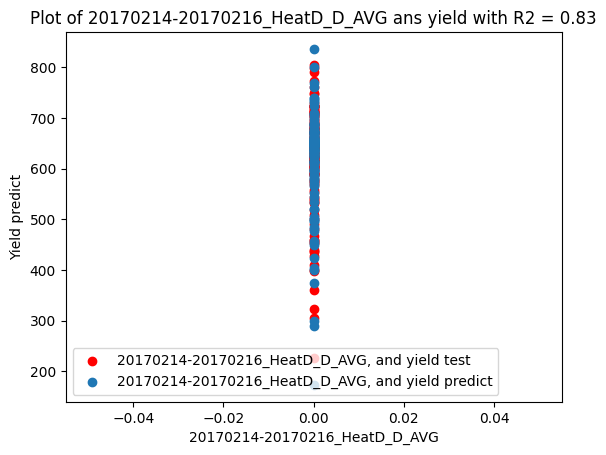

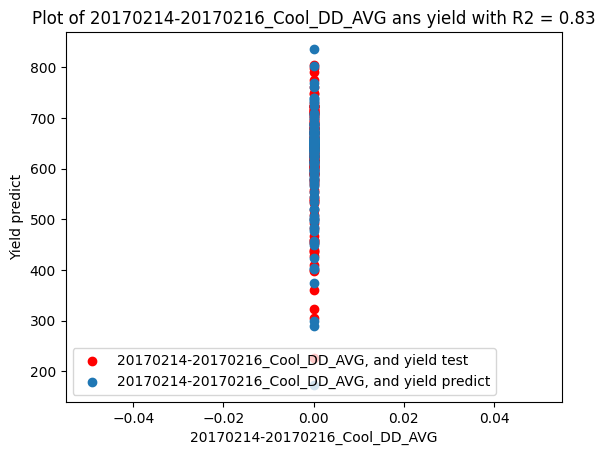

In [21]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [22]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 427.0, 'predict': 636.2504595620544, 'error': 0.4900479146652328},
 {'truth': 226.1118,
  'predict': 173.37598005015587,
  'error': 0.23322895996513282},
 {'truth': 532.0, 'predict': 643.3479713481198, 'error': 0.20930069802278162},
 {'truth': 799.0, 'predict': 652.7875098131401, 'error': 0.1829943556781726},
 {'truth': 804.0, 'predict': 657.000283174592, 'error': 0.18283546868831838},
 {'truth': 540.0, 'predict': 637.2601036193055, 'error': 0.18011130299871386},
 {'truth': 749.0, 'predict': 658.131356601037, 'error': 0.12131995113346188},
 {'truth': 748.0, 'predict': 659.9473587761938, 'error': 0.11771743479118472},
 {'truth': 625.0, 'predict': 697.125368109026, 'error': 0.1154005889744416},
 {'truth': 436.0, 'predict': 484.1823628317677, 'error': 0.11051000649488006},
 {'truth': 670.0, 'predict': 739.6339297904872, 'error': 0.10393123849326444},
 {'truth': 729.0, 'predict': 654.1467971301736, 'error': 0.10267929063076327},
 {'truth': 587.0, 'predict': 647.1963351397281, 'e